In [46]:
import numpy as np
import cv2
import glob

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objp = np.zeros((6*7,3), np.float32)
objp[:,:2] = np.mgrid[0:7,0:6].T.reshape(-1,2)

objpoints = []
imgpoints = []

images = glob.glob(r'C:\Users\U303-20\Desktop\IP2026\image2\**\*.png', recursive=True)
print(images)

for fname in images:
    img = cv2.imread(fname)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(
        gray, (7,6),
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    if ret:
        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)

        img = cv2.drawChessboardCorners(img, (7,6), corners2, ret)
        cv2.imshow('img', img)
        cv2.waitKey(500)

cv2.destroyAllWindows()

if len(objpoints) > 0:
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, gray.shape[::-1], None, None
    )

    print(mtx)
    print(dist)
else:
    print("no corners found")

['C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image50.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image51.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image52.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image53.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image54.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image55.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image56.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image57.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image58.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image59.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image60.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image61.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image62.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image63.png', 'C:\\Users\\U303-20\\Desktop\\IP2026\\image2\\Image\\image64.

In [47]:
len(images)

26

In [48]:
import numpy as np
import cv2
import glob
from matplotlib import pyplot as plt

In [49]:
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1],None,None)


In [10]:
mtx

array([[817.35833736,   0.        , 516.29970105],
       [  0.        , 797.37836967, 348.99059109],
       [  0.        ,   0.        ,   1.        ]])

In [11]:
dist

array([[ 2.80013466e-01, -2.99713130e+00, -6.00550025e-03,
         4.34355334e-03,  1.82919494e+01]])

In [ ]:
print(rvecs)

(array([[ 0.22767244],
       [-0.52568181],
       [-3.03590811]]), array([[ 0.01178437],
       [ 0.35880496],
       [-3.10182531]]), array([[-0.03607884],
       [ 0.24878772],
       [ 3.13026699]]))


In [13]:
tvecs

(array([[-2.94160159],
        [ 4.57084341],
        [17.80194172]]),)

In [53]:
# mmmmmm

In [57]:
img = cv2.imread('./Image2/image/image50.png')
h, w = img.shape[:2]
newcameramtx, roi=cv2.getOptimalNewCameraMatrix(mtx,dist,(w,h),1,(w,h))

In [58]:
# undistort
dst = cv2.undistort(img, mtx, dist, None, newcameramtx)
# crop the image
x,y,w,h = roi
dst = dst[y:y+h, x:x+w]
cv2.imwrite('calibresult.png',dst)

True

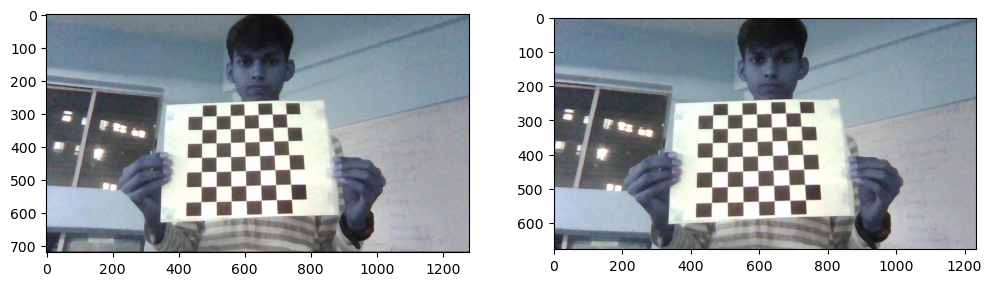

In [59]:
plt.figure(figsize=(12,8))
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(dst)
plt.show()
